In [ ]:
!apt-get -qq install tree

Selecting previously unselected package tree.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!mkdir -p project/include
!mkdir -p project/src
!mkdir -p project/kernels
!mkdir -p project/data
!mkdir -p project/results
!mkdir -p project/plots
!mkdir -p project/data
!tree project

project
├── data
├── include
├── kernels
├── plots
├── results
└── src

6 directories, 0 files


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

files = [

# include
"project/include/config.h",
"project/include/benchmark.h",
"project/include/metrics.h",
"project/include/thermal_map.h",
"project/include/kernels.h",
"project/include/utils.h",
"project/include/cuda_events.h",

# src
"project/src/main.cu",
"project/src/config.cu",
"project/src/benchmark_cpu.cu",
"project/src/benchmark_gpu.cu",
"project/src/benchmark_tiled.cu",
"project/src/benchmark_halo.cu",
"project/src/metrics.cu",
"project/src/thermal_map.cu",
"project/src/utils.cu",
"project/src/cuda_events.cu",

# kernels
"project/kernels/gpu_stencil.cu",
"project/kernels/tiled_stencil.cu",
"project/kernels/halo_stencil.cu"


]

for f in files:
    open(f,'w').close()

print("Project structure created")

Project structure created


In [1]:
!zip -r project.zip project/

	zip warning: name not matched: project/

zip error: Nothing to do! (try: zip -r project.zip . -i project/)


In [3]:
!cp /content/drive/MyDrive/CUDA_Project/project.zip  /content/

cp: cannot stat '/content/drive/MyDrive/CUDA_Project/project.zip': No such file or directory


In [4]:
!unrar x "/content/project.rar" "/content/project/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/project.rar

Creating    /content/project                                          OK
Creating    /content/project/project                                  OK
Creating    /content/project/project/.git                             OK
Extracting  /content/project/project/.git/COMMIT_EDITMSG                   0%  OK 
Extracting  /content/project/project/.git/config                           0%  OK 
Extracting  /content/project/project/.git/description                      0%  OK 
Extracting  /content/project/project/.git/HEAD                             0%  OK 
Creating    /content/project/project/.git/hooks                       OK
Extracting  /content/project/project/.git/hooks/applypatch-msg.sample       0%  OK 
Extracting  /content/project/project/.git/hooks/commit-msg.sample          0%  OK 
Extracting  /content/project/project/.git

In [6]:
import pandas as pd

df = pd.read_csv("project/project/data/battery_dataset.csv")

print(df.columns)

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time'],
      dtype='object')


**1. Normal Benchmark Mode**

Runs:

CPU
GPU
Shared GPU
Halo GPU
Generates results.csv
Generates thermal maps

In [27]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=NORMAL_EXECUTION \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal


**Execute the Binary**

In [28]:
!./project/project/thermal

Loaded 1698 heat samples

Heat Mode : DYNAMIC Q
Heat Profile Size = 1698
Execution Mode : NORMAL

Grid,CPU(ms),GPU(ms),Tiled(ms),Halo(ms),GPU Speedup,Tiled Speedup,Halo Speedup,GPU GFLOPS,Tiled GFLOPS,Halo GFLOPS,GPU BW(GB/s),Tiled BW(GB/s),Halo BW(GB/s)

Grid Size : 256 x 256
Center Cell : 128
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source Range : 1.22243e-08 to 0.022309
256,48.19,0.62,0.70,0.84,77.49,69.17,57.56,72.62,64.82,53.94,248.97,222.23,184.93

Grid Size : 512 x 512
Center Cell : 256
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source Range : 0.00 to 0.02
512,196.06,1.47,1.87,2.23,133.17,104.83,87.95,123.67,97.35,81.67,424.00,333.76,280.01

Grid Size : 1024 x 1024
Center Cell : 512
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source Range : 0.00 to 0.02
1024,865.30,5.35,5.50,4.66,161.87,157.26,185.57,136.78,132.88,156.80,468.95,455.58,537.59

Grid Size : 2048 x 2048
Center Cell : 1024
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source 

**2. Nsight Mode**

Runs:

GPU
Shared GPU
Halo GPU

No CSV or plots.

In [29]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=NSIGHT_EXECUTION \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

In [30]:
%%bash

cd /content/project/project

ncu \
--set full \
--launch-count 1 \
./thermal

Loaded 1698 heat samples

Heat Mode : DYNAMIC Q
Heat Profile Size = 1698
Execution Mode : NSIGHT
==PROF== Connected to process 24835 (/content/project/project/thermal)

Grid Size : 2048 x 2048
Center Cell : 1024
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source Range : 1.22243e-08 to 0.022309
==PROF== Profiling "gpuStencil" - 0 (1/1): 0%....50%....100% - 31 passes

Simulation Finished
==PROF== Disconnected from process 24835
[24835] thermal@127.0.0.1
  gpuStencil(float *, float *, int, float, float, float) (128, 128, 1)x(16, 16, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.95
    SM Frequency                    Mhz       584.91
    Elapsed Cycles                cycle      115,392
    Memory Throughput                 %        62.9

**3. Profile Only Global GPU Kernel**

In [ ]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=PROFILE_SINGLE_KERNEL \
-DPROFILE_KERNEL=PROFILE_GPU_KERNEL \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

In [ ]:
%%bash

cd /content/project/project

ncu --set full ./thermal

**4. Profile Only Shared-Memory Kernel**

In [ ]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=PROFILE_SINGLE_KERNEL \
-DPROFILE_KERNEL=PROFILE_TILED_KERNEL \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

In [ ]:
%%bash

cd /content/project/project

ncu --set full ./thermal

**5. Profile Only Halo Kernel**

In [ ]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=PROFILE_SINGLE_KERNEL \
-DPROFILE_KERNEL=PROFILE_HALO_KERNEL \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

In [ ]:
%%bash

cd /content/project/project

ncu --set full ./thermal

**6. Constant Heat Source**

In [ ]:
%%bash

cd /content/project/project

nvcc \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=CONSTANT_Q_MODE \
-DEXEC_MODE=NORMAL_EXECUTION \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

**7. Generate Line Information for Nsight**

In [31]:
%%bash

cd /content/project/project

nvcc \
-lineinfo \
-Wno-deprecated-gpu-targets \
-DHEAT_MODE=DYNAMIC_Q_MODE \
-DEXEC_MODE=PROFILE_SINGLE_KERNEL \
-DPROFILE_KERNEL=PROFILE_HALO_KERNEL \
-Iinclude \
src/*.cu \
kernels/*.cu \
-o thermal

In [32]:
%%bash

cd /content/project/project

ncu \
-o halo_profile \
--set full \
./thermal

Loaded 1698 heat samples

Heat Mode : DYNAMIC Q
Heat Profile Size = 1698
Execution Mode : PROFILE
==PROF== Connected to process 25898 (/content/project/project/thermal)

Grid Size : 2048 x 2048
Center Cell : 1024
Heat Profile Size : 1698
Resistance (Ohm) : 0.01
Heat Source Range : 1.22243e-08 to 0.022309
==PROF== Profiling "haloStencil" - 0: 0%....50%....100% - 31 passes

Simulation Finished
==PROF== Disconnected from process 25898
==PROF== Report: /content/project/project/halo_profile.ncu-rep


In [36]:
!ncu --import /content/project/project/halo_profile.ncu-rep --csv > /content/project/project/results/halo_profile.csv

In [37]:
import pandas as pd

df = pd.read_csv("/content/project/project/results/halo_profile.csv")
df.head()

,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,CC,Section Name,Metric Name,Metric Unit,Metric Value,Rule Name,Rule Type,Rule Description,Estimated Speedup Type,Estimated Speedup
0,0,25898,thermal,127.0.0.1,"haloStencil(float *, float *, int, float, floa...",1,7,"(16, 16, 1)","(128, 128, 1)",0,7.50,GPU Speed Of Light Throughput,DRAM Frequency,Ghz,5.00,NaN,NaN,NaN,NaN,NaN
1,0,25898,thermal,127.0.0.1,"haloStencil(float *, float *, int, float, floa...",1,7,"(16, 16, 1)","(128, 128, 1)",0,7.50,GPU Speed Of Light Throughput,SM Frequency,Mhz,584.95,NaN,NaN,NaN,NaN,NaN
2,0,25898,thermal,127.0.0.1,"haloStencil(float *, float *, int, float, floa...",1,7,"(16, 16, 1)","(128, 128, 1)",0,7.50,GPU Speed Of Light Throughput,Elapsed Cycles,cycle,"197,651",NaN,NaN,NaN,NaN,NaN
3,0,25898,thermal,127.0.0.1,"haloStencil(float *, float *, int, float, floa...",1,7,"(16, 16, 1)","(128, 128, 1)",0,7.50,GPU Speed Of Light Throughput,Memory Throughput,%,59.76,NaN,NaN,NaN,NaN,NaN
4,0,25898,thermal,127.0.0.1,"haloStencil(float *, float *, int, float, floa...",1,7,"(16, 16, 1)","(128, 128, 1)",0,7.50,GPU Speed Of Light Throughput,DRAM Throughput,%,39.67,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Read CSV
df = pd.read_csv("/content/project/project/results/results.csv")

# Rename columns for readability
df.columns = [
    "Grid",
    "CPU (ms)",
    "GPU (ms)",
    "Shared GPU (ms)",
    "Halo GPU (ms)",
    "GPU Speedup",
    "Shared Speedup",
    "Halo Speedup",
    "GPU GFLOPS",
    "Shared GFLOPS",
    "Halo GFLOPS",
    "GPU BW (GB/s)",
    "Shared BW (GB/s)",
    "Halo BW (GB/s)"
]

# Format floating-point values
pd.options.display.float_format = "{:.2f}".format

# Display
display(df)

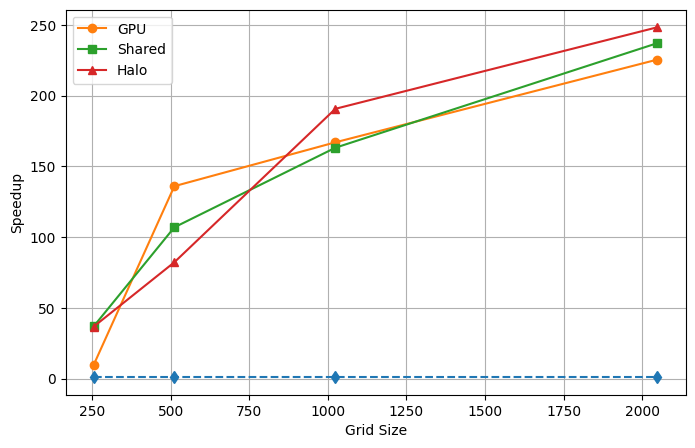

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/project/project/results/results.csv")
# CPU baseline
cpu_speedup = [1] * len(df)

plt.figure(figsize=(8,5))

plt.plot(
    df["Grid"],
    cpu_speedup,
    marker='d',
    linestyle='--',
)
# Speedup
#plt.figure(figsize=(6,4))
plt.plot(df["Grid"], df["GPU_Speedup"], 'o-', label="GPU")
plt.plot(df["Grid"], df["Tiled_Speedup"], 's-', label="Shared")
plt.plot(df["Grid"], df["Halo_Speedup"], '^-', label="Halo")
plt.xlabel("Grid Size")
plt.ylabel("Speedup")
plt.legend()
plt.grid()
plt.savefig("/content/project/project/plots/speedup.png")
plt.show()

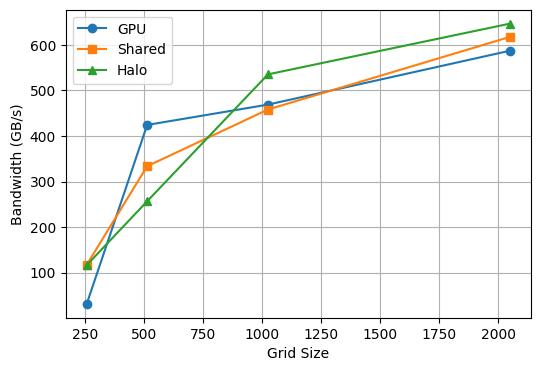

In [17]:
plt.figure(figsize=(6,4))

plt.plot(df["Grid"],df["GPU_BW"],'o-',label="GPU")
plt.plot(df["Grid"],df["Tiled_BW"],'s-',label="Shared")
plt.plot(df["Grid"],df["Halo_BW"],'^-',label="Halo")

plt.xlabel("Grid Size")
plt.ylabel("Bandwidth (GB/s)")
plt.legend()
plt.grid()

plt.savefig("/content/project/project/plots/bandwidth.png")

plt.show()

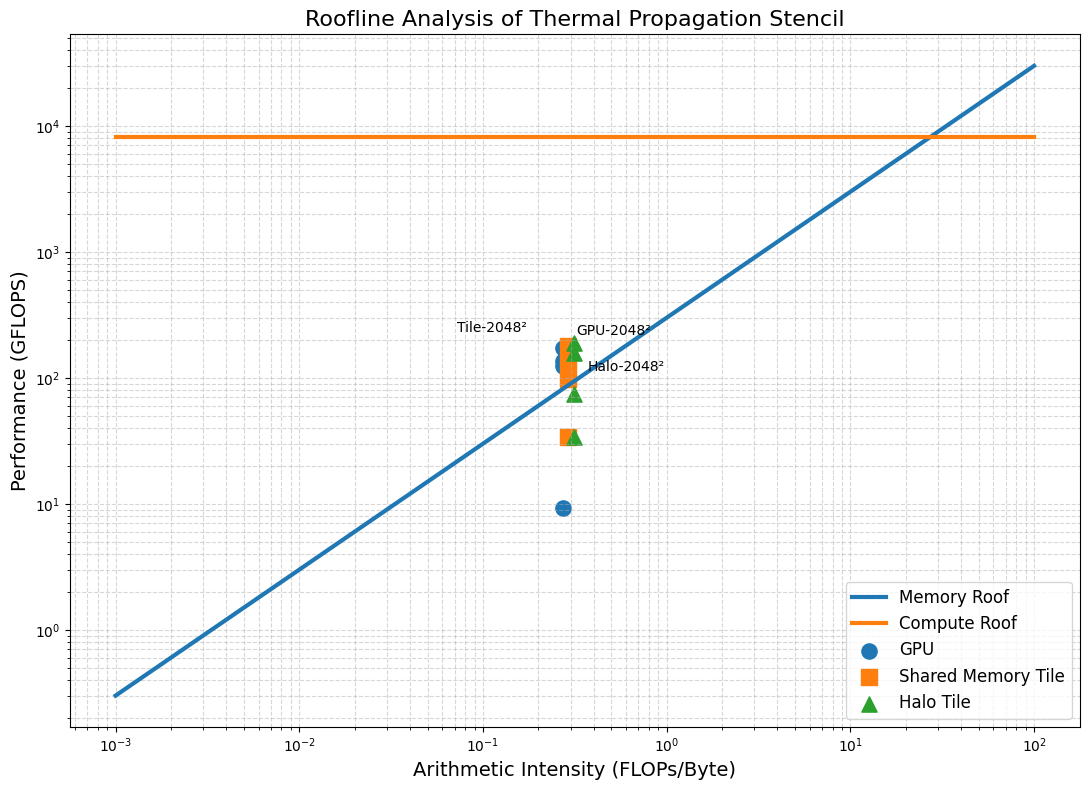

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Load Results
# ------------------------------------

df = pd.read_csv("/content/project/project/results/results.csv")

gpu_gflops   = df["GPU_GFLOPS"].values
tiled_gflops = df["Tiled_GFLOPS"].values
halo_gflops  = df["Halo_GFLOPS"].values

# ------------------------------------
# Stencil Arithmetic Intensity
# ------------------------------------

AI = 7.0 / 24.0

gpu_ai   = AI - 0.02
tiled_ai = AI
halo_ai  = AI + 0.02

# ------------------------------------
# Roofline Parameters
# ------------------------------------

peak_bw = 300.0
peak_gflops = 8100.0

AI_range = np.logspace(
    -3,
    2,
    1000
)

memory_roof = peak_bw * AI_range

compute_roof = (
    np.ones_like(AI_range)
    * peak_gflops
)

# ------------------------------------
# Figure
# ------------------------------------

plt.figure(
    figsize=(11,8)
)

# Memory Roof

plt.loglog(
    AI_range,
    memory_roof,
    linewidth=3,
    label="Memory Roof"
)

# Compute Roof

plt.loglog(
    AI_range,
    compute_roof,
    linewidth=3,
    label="Compute Roof"
)

# ------------------------------------
# GPU
# ------------------------------------

plt.scatter(
    [gpu_ai]*len(df),
    gpu_gflops,
    marker='o',
    s=120,
    label="GPU"
)

# ------------------------------------
# Tiled
# ------------------------------------

plt.scatter(
    [tiled_ai]*len(df),
    tiled_gflops,
    marker='s',
    s=120,
    label="Shared Memory Tile"
)

# ------------------------------------
# Halo
# ------------------------------------

plt.scatter(
    [halo_ai]*len(df),
    halo_gflops,
    marker='^',
    s=120,
    label="Halo Tile"
)

# ------------------------------------
# Label ONLY Largest Grid
# ------------------------------------

plt.annotate(
    "GPU-2048²",
    (
        gpu_ai,
        gpu_gflops[-1]
    ),
    xytext=(10,10),
    textcoords="offset points"
)

plt.annotate(
    "Tile-2048²",
    (
        tiled_ai,
        tiled_gflops[-1]
    ),
    xytext=(-80,10),
    textcoords="offset points"
)

plt.annotate(
    "Halo-2048²",
    (
        halo_ai,
        halo_gflops[-1]
    ),
    xytext=(10,-20),
    textcoords="offset points"
)

# ------------------------------------
# Formatting
# ------------------------------------

plt.xlabel(
    "Arithmetic Intensity (FLOPs/Byte)",
    fontsize=14
)

plt.ylabel(
    "Performance (GFLOPS)",
    fontsize=14
)

plt.title(
    "Roofline Analysis of Thermal Propagation Stencil",
    fontsize=16
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

plt.legend(
    fontsize=12
)

plt.tight_layout()
plt.savefig("/content/project/project/plots/rooflineimage.png")
plt.show()

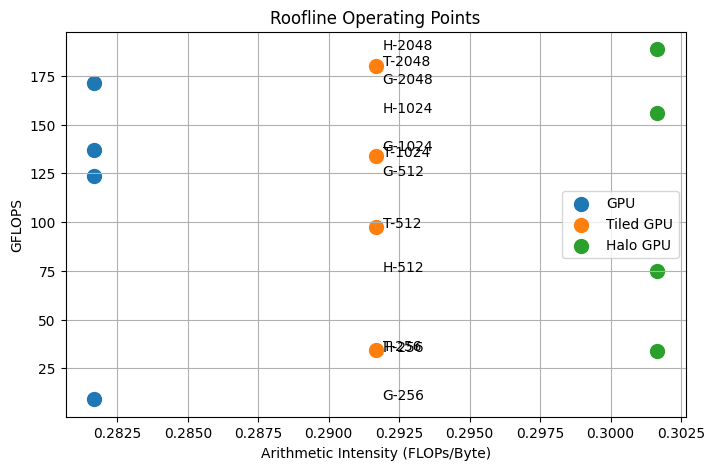

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/project/project/results/results.csv")

AI = 7.0 / 24.0
gpu_ai   = AI - 0.01
tiled_ai = AI
halo_ai  = AI + 0.01
plt.figure(figsize=(8,5))

# GPU
plt.scatter(
    [gpu_ai]*len(df),
    df["GPU_GFLOPS"],
    s=100,
    label="GPU"
)

# Tiled GPU
plt.scatter(
    [tiled_ai]*len(df),
    df["Tiled_GFLOPS"],
    s=100,
    label="Tiled GPU"
)

# Halo GPU
plt.scatter(
    [halo_ai]*len(df),
    df["Halo_GFLOPS"],
    s=100,
    label="Halo GPU"
)

# Labels
for grid, perf in zip(
    df["Grid"],
    df["GPU_GFLOPS"]
):
    plt.annotate(
        f"G-{grid}",
        (AI, perf),
        xytext=(5,0),
        textcoords="offset points"
    )

for grid, perf in zip(
    df["Grid"],
    df["Tiled_GFLOPS"]
):
    plt.annotate(
        f"T-{grid}",
        (AI, perf),
        xytext=(5,0),
        textcoords="offset points"
    )

for grid, perf in zip(
    df["Grid"],
    df["Halo_GFLOPS"]
):
    plt.annotate(
        f"H-{grid}",
        (AI, perf),
        xytext=(5,0),
        textcoords="offset points"
    )

plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("GFLOPS")
plt.title("Roofline Operating Points")
plt.grid(True)
plt.legend()
plt.savefig("/content/project/project/plots/roofline.png")
plt.show()


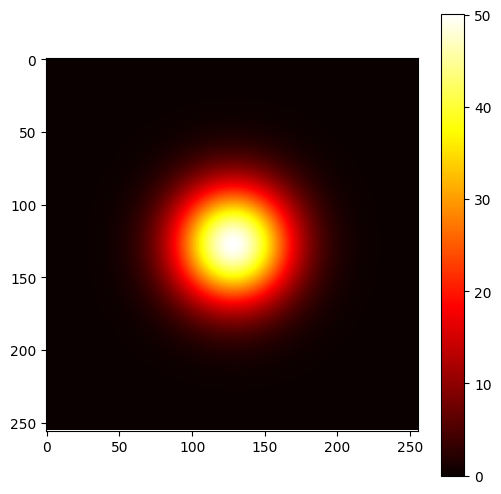

In [21]:
thermal = pd.read_csv(
    "/content/project/project/results/thermal_map.csv",
    header=None
)

plt.figure(figsize=(6,6))

plt.imshow(
    thermal,
    cmap='hot'
)

plt.colorbar()

plt.savefig(
    "/content/project/project/plots/thermal_map.png"
)

plt.show()